# 01 · EDA & Preprocessing
**Dataset:** German Credit Data (`../data/raw/german_credit_data_updated.csv`)


# Credit Risk Analysis — EDA, Preprocessing, Modeling & Evaluation
**Dataset:** German Credit Data (`german_credit_data_updated.csv`)
## 🔑 5 Insight Utama dari EDA

1. **Data imbalance.** Kelas target tidak seimbang: 69.7% nasabah *good* (label 1) vs
   30.3% *bad* (label 2). Ini penting — model harus dievaluasi dengan Recall/F1/ROC-AUC,
   bukan hanya Accuracy, dan tuning perlu mempertimbangkan `class_weight='balanced'`.

2. **Jumlah kredit & durasi berkorelasi kuat (r=0.63)** dan keduanya lebih tinggi pada
   nasabah *bad*: rata-rata Credit amount nasabah bad = **3,934** vs good = **2,995**;
   rata-rata Duration bad = **24.6 bulan** vs good = **19.1 bulan**. Kredit besar dengan
   tenor panjang berasosiasi dengan risiko lebih tinggi.

3. **Status rekening giro (Checking account) adalah sinyal risiko terkuat.** Bad-rate
   menurun tajam seiring saldo membaik: `little` = 49.8% bad, `moderate` = 39.8% bad,
   `rich` = 23.7% bad. Pola serupa (lebih lemah) juga terlihat pada `Saving accounts`.

4. **Tujuan kredit (Purpose) memengaruhi risiko.** Bad-rate tertinggi pada
   `vacation/others` (41.7%) dan `repairs` (40.0%), sedangkan `radio/TV` paling rendah
   (22.5%) — kredit konsumtif kecil relatif lebih aman dibanding kredit gaya hidup/darurat.

5. **Kepemilikan rumah (Housing) berpola serupa:** nasabah dengan rumah sendiri (`own`)
   punya bad-rate paling rendah (26.5%) dibanding yang menyewa (39.1%) atau tinggal gratis
   (41.0%) — mengindikasikan stabilitas tempat tinggal berkorelasi dengan kelayakan kredit.





## 1. Import Library

In [30]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, RandomizedSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, auc, confusion_matrix, classification_report
)

import shap

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
print('Semua library berhasil di-import.')

Semua library berhasil di-import.


## 2. Eksploratory Data Analysis (EDA) 

Catatan: kolom `Unnamed: 0` adalah kolom index/ID bawaan CSV, bukan fitur — akan
di-drop pada tahap feature engineering.

In [31]:
df = pd.read_csv('../data/raw/german_credit_data_updated.csv')
print('Ukuran dataset:', df.shape)
df.info()

Ukuran dataset: (954, 11)
<class 'pandas.DataFrame'>
RangeIndex: 954 entries, 0 to 953
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Unnamed: 0        954 non-null    int64
 1   Age               954 non-null    int64
 2   Sex               954 non-null    str  
 3   Job               954 non-null    int64
 4   Housing           954 non-null    str  
 5   Saving accounts   779 non-null    str  
 6   Checking account  576 non-null    str  
 7   Credit amount     954 non-null    int64
 8   Duration          954 non-null    int64
 9   Purpose           954 non-null    str  
 10  Credit Risk       954 non-null    int64
dtypes: int64(6), str(5)
memory usage: 106.4 KB


In [32]:
df.head()

,Unnamed: 0,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Credit Risk
0,0,67,male,2,own,NaN,little,1169,6,radio/TV,1
1,1,22,female,2,own,little,moderate,5951,48,radio/TV,2
2,2,49,male,1,own,little,NaN,2096,12,education,1
3,3,45,male,2,free,little,little,7882,42,furniture/equipment,1
4,4,53,male,2,free,little,little,4870,24,car,2


==== Info dataset =====


NameError: name 'df' is not defined

In [33]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Unnamed: 0,954.0,NaN,NaN,NaN,476.5,275.540378,0.0,238.25,476.5,714.75,953.0
Age,954.0,NaN,NaN,NaN,35.501048,11.379668,19.0,27.0,33.0,42.0,75.0
Sex,954,2,male,656,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Job,954.0,NaN,NaN,NaN,1.909853,0.649681,0.0,2.0,2.0,2.0,3.0
Housing,954,3,own,680,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Saving accounts,779,4,little,576,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Checking account,576,3,little,261,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Credit amount,954.0,NaN,NaN,NaN,3279.112159,2853.315158,250.0,1360.25,2302.5,3975.25,18424.0
Duration,954.0,NaN,NaN,NaN,20.780922,12.046483,4.0,12.0,18.0,24.0,72.0
Purpose,954,8,car,322,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 3. Data Processing

Mengecek 4 aspek kualitas data: **duplikat, missing value, outlier, dan inkonsistensi**
sebelum data diproses lebih lanjut.

### 3.1 Duplikat

In [20]:
n_dup = df.duplicated().sum()
print(f'Jumlah baris duplikat: {n_dup}')

Jumlah baris duplikat: 0


**Hasil:** tidak ditemukan baris duplikat pada dataset ini, sehingga tidak perlu
langkah `drop_duplicates()`.

### 3.2 Missing Value

                  missing_count  missing_pct
Checking account            378        39.62
Saving accounts             175        18.34


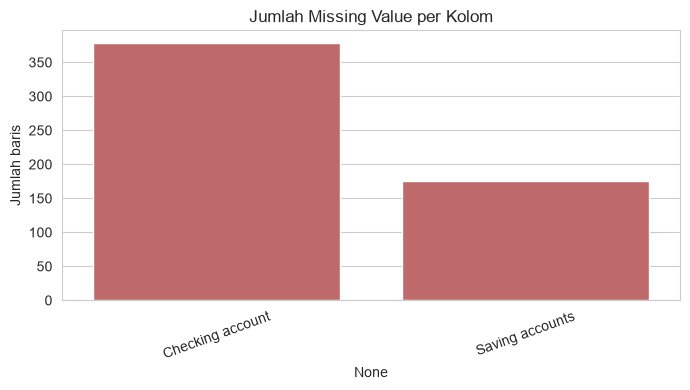

In [21]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'missing_count': missing, 'missing_pct': missing_pct})
missing_df = missing_df[missing_df['missing_count'] > 0].sort_values('missing_count', ascending=False)
print(missing_df)

plt.figure(figsize=(7,4))
sns.barplot(x=missing_df.index, y=missing_df['missing_count'], color='indianred')
plt.title('Jumlah Missing Value per Kolom')
plt.ylabel('Jumlah baris')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

**Hasil & Justifikasi Penanganan:**
- `Saving accounts` hilang pada 175 baris (~18%), `Checking account` hilang pada 378 baris (~40%).
- Ini **bukan** missing-at-random biasa: dalam konteks data kredit, nasabah yang tidak
  memiliki rekening tabungan/giro sama sekali sangat mungkin menghasilkan nilai kosong.
  Karena itu **tidak dilakukan `dropna()`** (yang akan membuang hampir separuh data),
  melainkan nilai kosong diimputasi sebagai kategori baru **`"none"`** — pendekatan yang
  mempertahankan informasi sekaligus menjaga ukuran data. Implementasinya ada di
  pipeline preprocessing (Bagian 6).

### 3.3 Outlier (metode IQR)

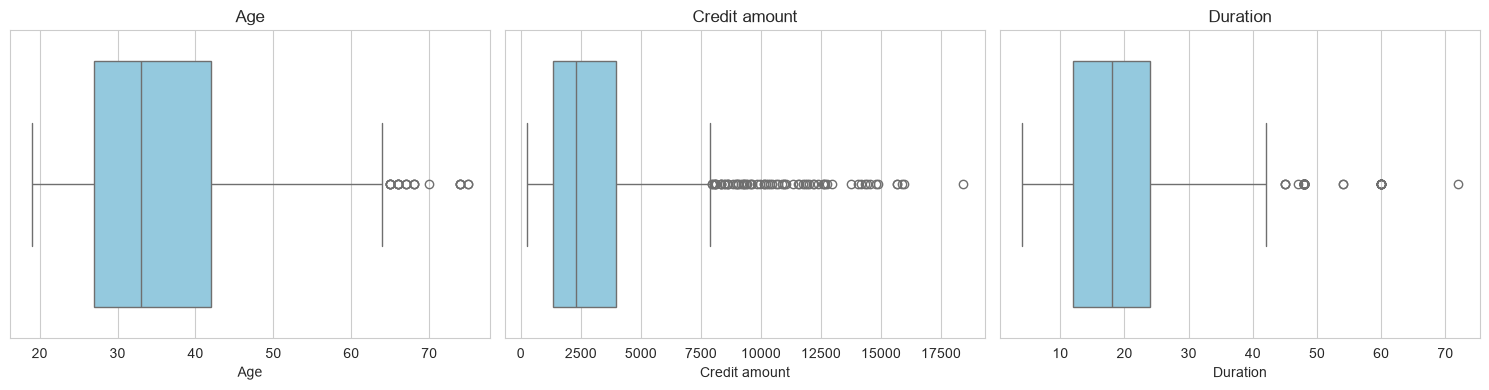

,Q1,Q3,IQR,lower_bound,upper_bound,n_outliers,pct_outliers
Age,27.00,42.00,15.0,4.50,64.50,23.0,2.41
Credit amount,1360.25,3975.25,2615.0,-2562.25,7897.75,70.0,7.34
Duration,12.00,24.00,12.0,-6.00,42.00,66.0,6.92


In [22]:
numeric_cols = ['Age', 'Credit amount', 'Duration']

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
outlier_summary = {}
for i, col in enumerate(numeric_cols):
    Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5*IQR, Q3 + 1.5*IQR
    n_out = ((df[col] < lower) | (df[col] > upper)).sum()
    outlier_summary[col] = {'Q1': Q1, 'Q3': Q3, 'IQR': IQR,
                             'lower_bound': lower, 'upper_bound': upper,
                             'n_outliers': n_out, 'pct_outliers': round(n_out/len(df)*100, 2)}
    sns.boxplot(x=df[col], ax=axes[i], color='skyblue')
    axes[i].set_title(col)
plt.tight_layout()
plt.show()

pd.DataFrame(outlier_summary).T

**Hasil & Justifikasi Penanganan:**
- Ketiga kolom numerik memiliki outlier wajar (nasabah dengan kredit besar/durasi
  panjang), bukan kesalahan input data — nilainya valid secara bisnis.
- Karena algoritma yang dipakai nanti (Random Forest, XGBoost) **tidak sensitif** terhadap
  outlier, dan Logistic Regression akan memakai *robust* `StandardScaler` setelah split,
  outlier **tidak dihapus/di-clip**, cukup dipantau. Menghapusnya berisiko membuang
  nasabah "ekstrem" yang justru penting untuk mendeteksi risiko kredit tinggi.

### 3.4 Inkonsistensi Data (tipe data & kategori)

In [23]:
cat_cols = df.select_dtypes(include='object').columns.tolist()
for col in cat_cols:
    print(f'{col}: {sorted(df[col].dropna().unique().tolist())}')

print('\nJob (kode ordinal skill level):', sorted(df['Job'].unique()))
print('\nCredit Risk (target):', sorted(df['Credit Risk'].unique()))

Sex: ['female', 'male']
Housing: ['free', 'own', 'rent']
Saving accounts: ['little', 'moderate', 'quite rich', 'rich']
Checking account: ['little', 'moderate', 'rich']
Purpose: ['business', 'car', 'domestic appliances', 'education', 'furniture/equipment', 'radio/TV', 'repairs', 'vacation/others']

Job (kode ordinal skill level): [np.int64(0), np.int64(1), np.int64(2), np.int64(3)]

Credit Risk (target): [np.int64(1), np.int64(2)]


**Hasil:** tidak ditemukan inkonsistensi penulisan kategori (typo, kapitalisasi ganda,
dsb). `Job` adalah kode ordinal (0=unskilled non-resident … 3=highly skilled) sehingga
tetap diperlakukan sebagai fitur numerik/ordinal. Target `Credit Risk` bernilai `1`
(good/layak) dan `2` (bad/tidak layak) — akan di-encode ulang menjadi biner `0/1` agar
tidak ambigu (lihat Bagian 5).

## 4. Analisis Univariat & Multivariat

### 4.1 Distribusi Target

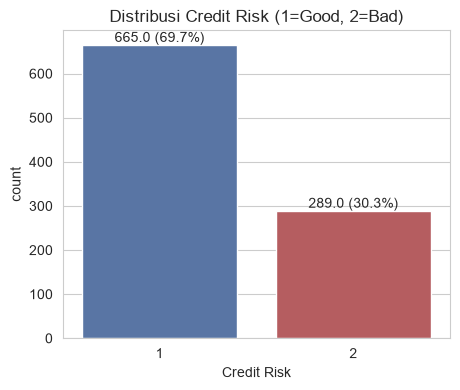

In [24]:
plt.figure(figsize=(5,4))
ax = sns.countplot(x='Credit Risk', data=df, palette=['#4C72B0', '#C44E52'])
plt.title('Distribusi Credit Risk (1=Good, 2=Bad)')
for p in ax.patches:
    ax.annotate(f'{p.get_height()} ({p.get_height()/len(df)*100:.1f}%)',
                (p.get_x()+p.get_width()/2, p.get_height()), ha='center', va='bottom')
plt.show()

### 4.2 Distribusi Fitur Numerik

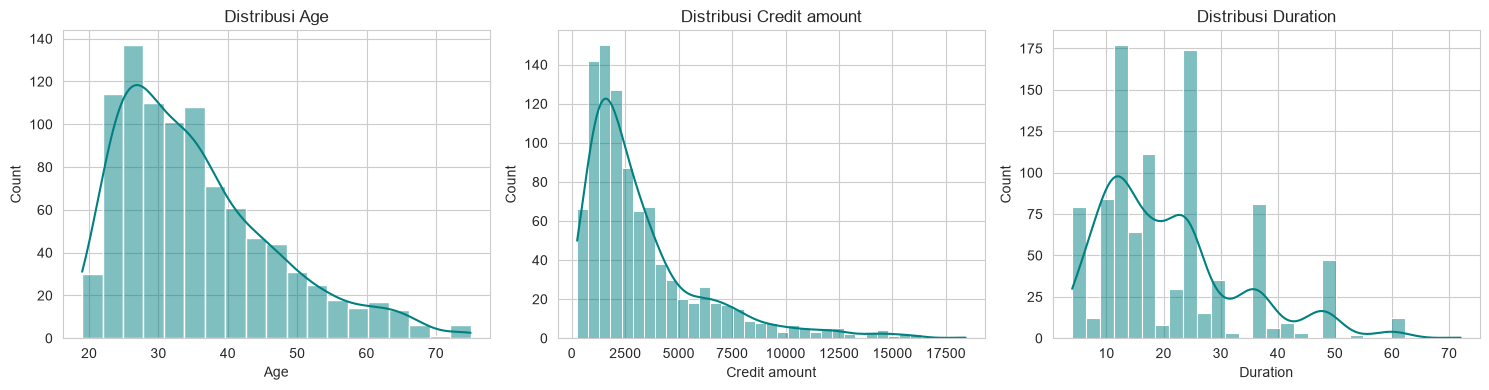

In [25]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for i, col in enumerate(numeric_cols):
    sns.histplot(df[col], kde=True, ax=axes[i], color='teal')
    axes[i].set_title(f'Distribusi {col}')
plt.tight_layout()
plt.show()

### 4.3 Fitur Numerik vs Target

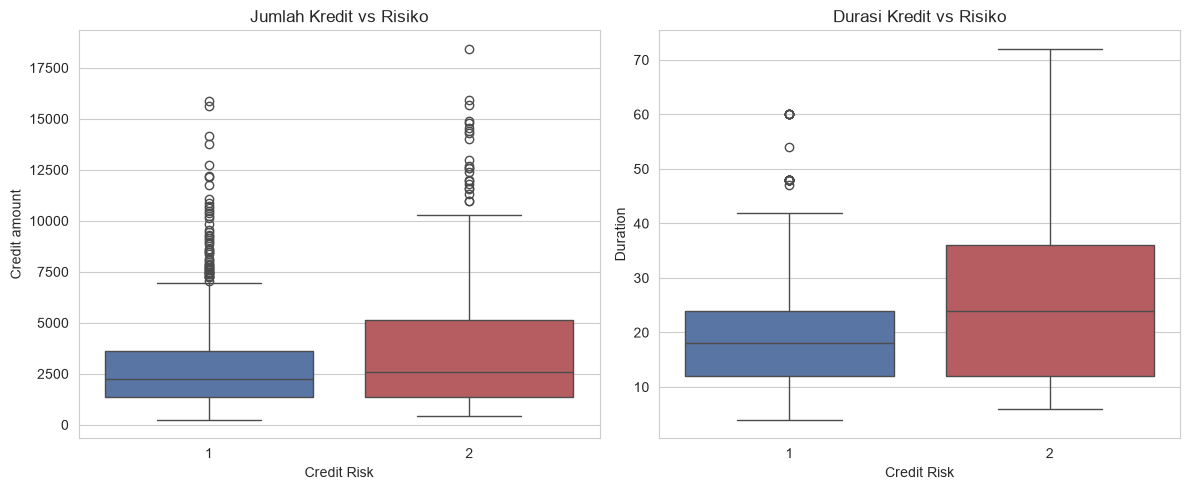

             Credit amount  Duration
Credit Risk                         
1                   2994.5      19.1
2                   3934.0      24.6


In [26]:
fig, axes = plt.subplots(1, 2, figsize=(12,5))
sns.boxplot(data=df, x='Credit Risk', y='Credit amount', ax=axes[0], palette=['#4C72B0','#C44E52'])
axes[0].set_title('Jumlah Kredit vs Risiko')
sns.boxplot(data=df, x='Credit Risk', y='Duration', ax=axes[1], palette=['#4C72B0','#C44E52'])
axes[1].set_title('Durasi Kredit vs Risiko')
plt.tight_layout()
plt.show()

print(df.groupby('Credit Risk')[['Credit amount','Duration']].mean().round(1))

### 4.4 Fitur Kategorikal vs Target

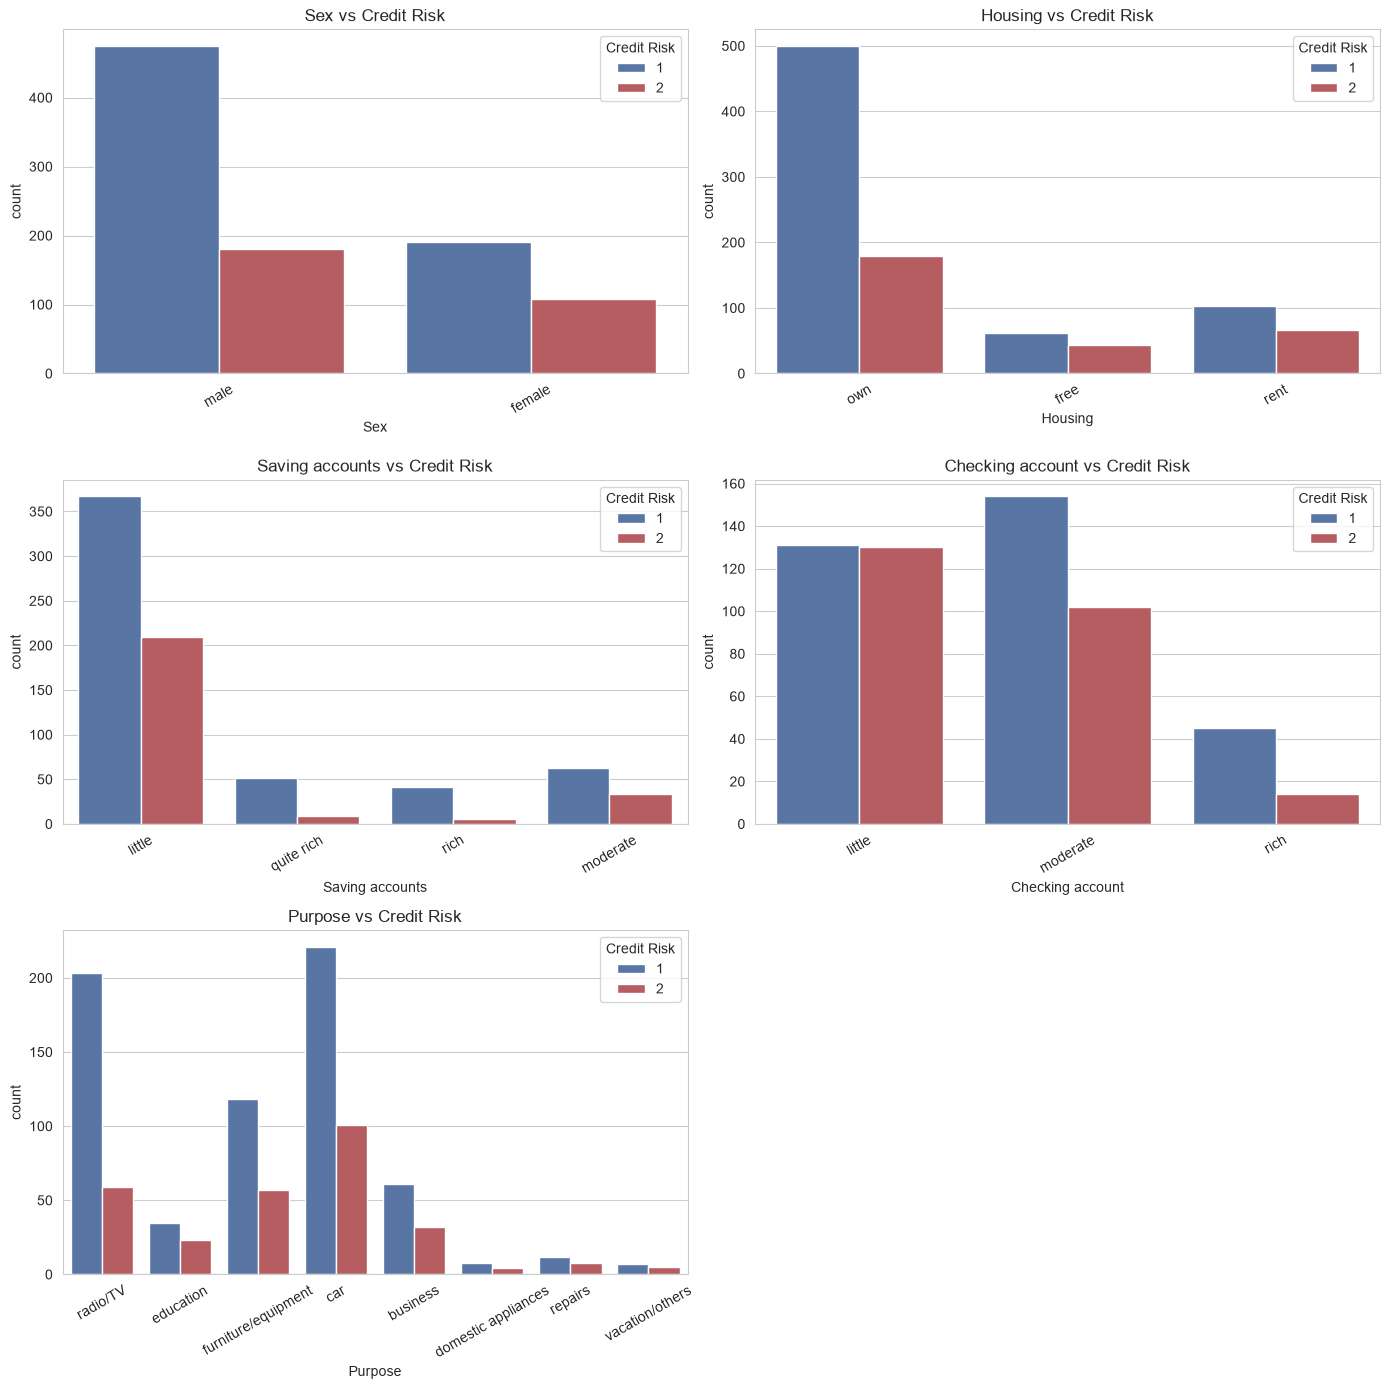

In [27]:
cat_features = ['Sex', 'Housing', 'Saving accounts', 'Checking account', 'Purpose']
fig, axes = plt.subplots(3, 2, figsize=(14, 14))
axes = axes.flatten()
for i, col in enumerate(cat_features):
    sns.countplot(data=df, x=col, hue='Credit Risk', ax=axes[i], palette=['#4C72B0','#C44E52'])
    axes[i].set_title(f'{col} vs Credit Risk')
    axes[i].tick_params(axis='x', rotation=30)
axes[-1].axis('off')
plt.tight_layout()
plt.show()

### 4.5 Korelasi Antar Fitur Numerik

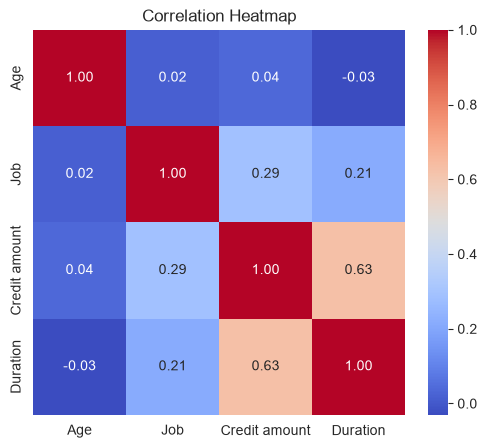

In [28]:
plt.figure(figsize=(6,5))
sns.heatmap(df[['Age','Job','Credit amount','Duration']].corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

### 4.6 Multivariate: Duration vs Credit Amount

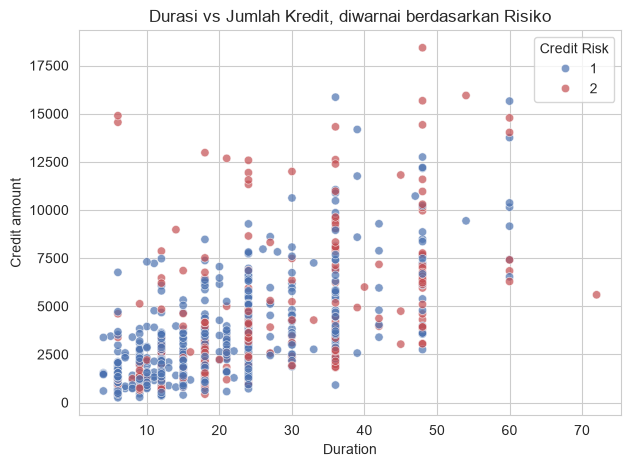

In [29]:
plt.figure(figsize=(7,5))
sns.scatterplot(data=df, x='Duration', y='Credit amount', hue='Credit Risk',
                 palette=['#4C72B0','#C44E52'], alpha=0.7)
plt.title('Durasi vs Jumlah Kredit, diwarnai berdasarkan Risiko')
plt.show()